# 07 · Backtest — M2 against the team's walks, on F1, F2 and F4

## Executive summary (read this first)

**The question:** on which cards does M2 forecast better than the walk the team already uses?

We now have three models (see `forecast_models.py`):

| model | centre | width | shape |
|---|---|---|---|
| **M2** | last value + μ from a ridge on features | σ from a ridge on volatility features | real historical residuals |
| **random walk** | last value | sd of the last 260 daily steps × √h | normal bell curve |
| **cumulative walk** | same as the random walk, but each draw is **one path**, so the horizons are linked | | |

For each card, production uses M2 (F1) or **the walk for the card's shape**: the cumulative walk when the
card has 2 horizons, the random walk when it has 1. So that is the fair comparison: **M2 ÷ that walk**.

**What we found** (numbers recomputed below; below 1 = M2 better):

- **F2:** M2 is worse. Keep the random walk.
- **F4 daily cards:** M2 is worse or tied. Keep the walk.
- **Monthly cards (2 in F1, 2 in F4):** M2 is much better. The walk had a bug on monthly panels: it read a
  21-business-day horizon as 21 *months*. That is **fixed on `feat/model_v2`** (§5), and M2 still wins
  against the fixed walk (0.47–0.83).
- **F1 daily cards:** M2 is about 7% worse than the cumulative walk in the backtest, and worse on real
  outcomes too (team eval). M2 used to beat the *old* walk, which drew each horizon independently; the
  cumulative walk fixed that weakness.

**Method in one line:** stand at many past dates inside each card's own history, forecast with each
model using only data up to that date, and score with the competition formula against what really
happened next in the panel. No sealed outcomes are used in §1–§6. §7 is the only section that uses
realized outcomes (the team's local eval).

## 0 — Setup

`RERUN = True` recomputes the backtest (about 30 seconds on 8 cores); otherwise the saved results are read.

In [1]:
import contextlib, io, json, pathlib, subprocess, sys, tempfile, tomllib, importlib
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "f1_pipeline" else pathlib.Path.cwd() / "f1_pipeline"
REPO, DATA = HERE.parent, HERE / "data"
for p in (str(HERE), str(REPO)):
    if p not in sys.path: sys.path.insert(0, p)
import m2_unit as m2, backtest_m2 as bt, forecast_models as fm, forecast_agent as fa
for mod in (m2, fm, fa, bt): importlib.reload(mod)

pd.set_option("display.width", 210); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
COL = {"M2": "#1baf7a", "random walk": "#2a78d6", "cumulative walk": "#eb6834"}
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})

RERUN = False
path = DATA / "backtest_m2_vs_walk.parquet"
if RERUN or not path.exists():
    dirs = [d for f in ("F1", "F2", "F4") for d in sorted((REPO / "units").glob(f"t2-{f}-*"))]
    raw = bt.run(dirs, workers=8); raw.to_parquet(path, index=False)
else:
    raw = pd.read_parquet(path)
ok = raw[raw.status == "ok"].copy()
print(f"{raw.unit.nunique()} cards read: {ok.unit.nunique()} backtested, {ok.origin.nunique():,} distinct dates, "
      f"{len(ok):,} forecasts scored")
raw[raw.status != "ok"].drop_duplicates("unit")[["unit", "family", "status"]]

81 cards read: 77 backtested, 2,081 distinct dates, 36,660 forecasts scored


,unit,family,status
12432,t2-F2-cnh-stress-2015,T2-F2,skipped: transfer card (target history has a d...
12433,t2-F2-cnh-tradewar-2018,T2-F2,skipped: transfer card (target history has a d...
15062,t2-F2-fragile-five-brl-2013,T2-F2,skipped: transfer card (target history has a d...
15063,t2-F2-fragile-five-inr-2013,T2-F2,skipped: transfer card (target history has a d...


## 1 — How the backtest works

For each card:

1. Build M2's features for the card's panel (notebook 01's code, through `m2_unit.build_features`).
2. Pick **origins**: every 21st date (every 2nd month on a monthly panel) at which every cell already has
   at least 252 training rows (60 monthly) whose outcome is known.
3. At each origin, forecast the card's cells three ways:
   - **M2**: `m2_unit.fit_m2(cell, origin=...)` — fitted only on rows whose outcome was known by then.
   - **random walk** and **cumulative walk**: the production functions, given the panel cut at the origin.
4. Score each forecast (1,000 draws) against what the panel shows the target did next, with the
   competition formula: **0.5 × CRPS + 0.3 × variogram + 0.2 × tail** (the weights every F1, F2 and F4
   card declares). Lower is better.

The walks get no text adjustment here: this compares the numeric models only.

**One card, to see it:** `t2-F1-ust-positioning-2018`, the 10-year yield at 126 and 189 business days.

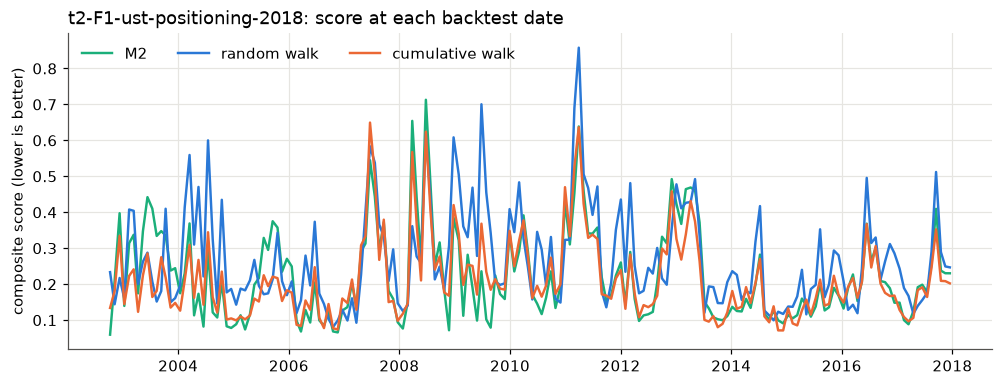

182 dates.  Mean score: M2 0.224, cumulative walk 0.214, random walk 0.271


In [2]:
one = ok[ok.unit == "t2-F1-ust-positioning-2018"].pivot_table(index="origin", columns="model", values="composite")
fig, ax = plt.subplots(figsize=(9, 3.4), layout="constrained")
for name in ("M2", "random walk", "cumulative walk"):
    ax.plot(one.index, one[name], color=COL[name], lw=1.6, label=name)
ax.set_ylabel("composite score (lower is better)")
ax.set_title("t2-F1-ust-positioning-2018: score at each backtest date")
ax.legend(ncols=3, loc="upper left"); plt.show()
print(f"{len(one)} dates.  Mean score: " + ", ".join(f"{k} {v:.3f}" for k, v in one.mean().items()))

## 2 — The comparison: M2 ÷ the walk production would use

For every date we take **ratio = M2's score ÷ the walk's score** (the cumulative walk on 2-horizon cards,
the random walk on 1-horizon cards). Below 1 means M2 was better on that date.

To average ratios we use the **geometric mean**. If M2 is twice as good on one date (0.5) and twice as bad
on another (2.0), the geometric mean says 1.0, a tie, which is fair. A plain average would say 1.25 and
blame M2 unfairly. We also show **how often M2 wins**.

Raw scores cannot be averaged across cards: a payrolls card scores in the hundreds, a yield card below 1, so
a plain average is decided by the big-unit cards. Ratios have no units, so they can be averaged.

In [3]:
w = ok.pivot_table(index=["family", "unit", "freq", "target_type", "horizons", "origin", "n_train"],
                  columns="model", values="composite").reset_index()
w["two_horizons"] = w.horizons.str.contains(",")
w["walk"] = np.where(w.two_horizons, w["cumulative walk"], w["random walk"])
w["walk_name"] = np.where(w.two_horizons, "cumulative walk", "random walk")
w["ratio"] = w["M2"] / w["walk"]
w["history"] = np.where(w.freq == "monthly", "monthly", np.where(w.n_train >= 1000, "daily, >= 1000 rows", "daily, < 1000 rows"))

def summarise(g):
    return pd.Series({"cards": g["unit"].nunique() if "unit" in g else 1, "dates": len(g),
                      "geo_mean_ratio": np.exp(np.log(g.ratio).mean()),
                      "M2_wins_%": 100 * (g.ratio < 1).mean()})

card = (w.groupby(["family", "unit", "freq", "target_type", "horizons", "walk_name"])
          .apply(summarise, include_groups=False).drop(columns="cards").reset_index())
fam = w.groupby("family").apply(summarise, include_groups=False)
fam["cards_M2_better"] = card.groupby("family").apply(lambda g: f"{(g.geo_mean_ratio < 1).sum()}/{len(g)}", include_groups=False)
fam.round(3)

,cards,dates,geo_mean_ratio,M2_wins_%,cards_M2_better
family,,,,,
T2-F1,23.0,3538.0,1.066,45.138,6/23
T2-F2,23.0,3758.0,1.038,43.720,4/23
T2-F4,31.0,4924.0,1.004,46.913,12/31


## 3 — It depends on how much history the card has, and on monthly vs daily

The same comparison, split by family, target type and history size. The dotted line is a tie.

,family,target_type,history,cards,dates,geo_mean_ratio,M2_wins_%
0,T2-F1,level,"daily, < 1000 rows",19.0,610.0,1.259,29.672
1,T2-F1,level,"daily, >= 1000 rows",16.0,2275.0,1.071,45.451
2,T2-F1,level,monthly,2.0,199.0,0.670,74.372
3,T2-F1,log_return,"daily, < 1000 rows",2.0,72.0,1.654,16.667
4,T2-F1,log_return,"daily, >= 1000 rows",2.0,382.0,0.932,58.115
5,T2-F2,level,"daily, < 1000 rows",23.0,811.0,1.064,41.677
6,T2-F2,level,"daily, >= 1000 rows",22.0,2947.0,1.031,44.282
7,T2-F4,level,"daily, < 1000 rows",18.0,648.0,1.028,44.907
8,T2-F4,level,"daily, >= 1000 rows",18.0,2381.0,1.037,43.763
9,T2-F4,level,monthly,2.0,181.0,0.562,82.873


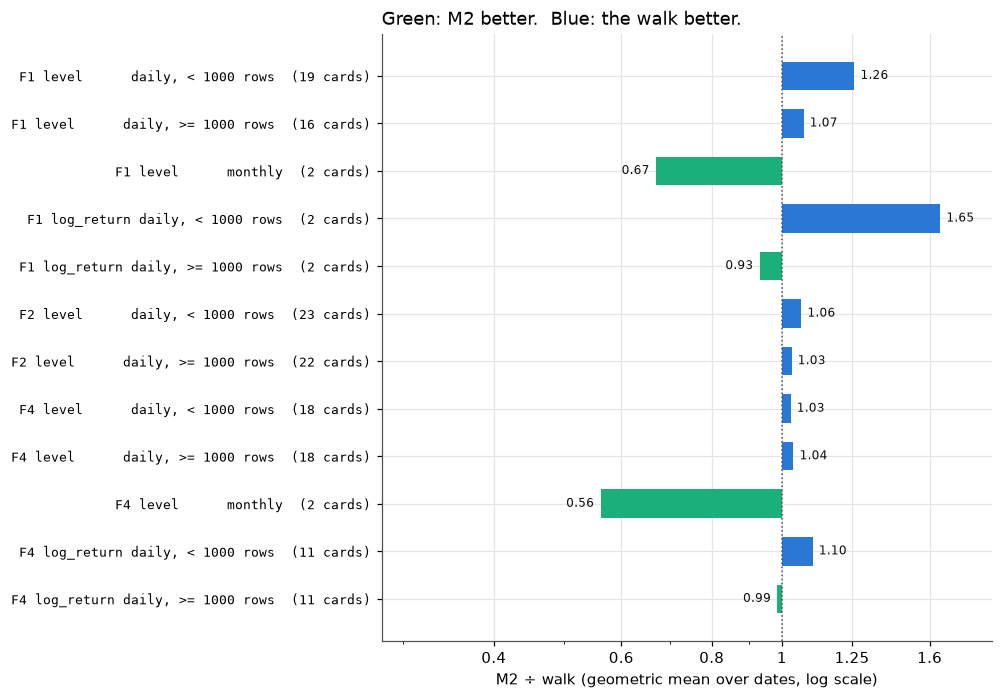

In [4]:
grp = w.groupby(["family", "target_type", "history"]).apply(summarise, include_groups=False).reset_index()
display(grp.round(3))

g = grp.sort_values(["family", "target_type", "history"]).reset_index(drop=True)
labels = [f"{r.family[3:]} {r.target_type:<10} {r.history}  ({int(r.cards)} cards)" for r in g.itertuples()]
fig, ax = plt.subplots(figsize=(9, 0.42 * len(g) + 1.2), layout="constrained")
colors = [COL["M2"] if v < 1 else COL["random walk"] for v in g.geo_mean_ratio]
ax.barh(range(len(g)), g.geo_mean_ratio - 1, left=1, color=colors, height=0.6)
ax.axvline(1, color=INK2, lw=1, ls=":")
ax.set_yticks(range(len(g)), labels, fontsize=8.5, family="monospace"); ax.invert_yaxis()
ax.set_xscale("log"); ax.set_xlim(0.28, 1.95)
ax.set_xticks([0.4, 0.6, 0.8, 1, 1.25, 1.6]); ax.set_xticklabels(["0.4", "0.6", "0.8", "1", "1.25", "1.6"])
ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
for i, v in enumerate(g.geo_mean_ratio):
    ax.text(v * (1.02 if v >= 1 else 0.98), i, f"{v:.2f}", va="center", ha="left" if v >= 1 else "right", fontsize=8, color=INK)
ax.set_xlabel("M2 ÷ walk (geometric mean over dates, log scale)")
ax.set_title("Green: M2 better.  Blue: the walk better.")
plt.show()

**How to read it:**

- **Short daily history (< 1,000 rows): the walk wins in every family.** This is the router we already
  added to F1 (notebook 03 §4.1).
- **Monthly panels: M2 wins clearly** (4 cards), against the walk with its monthly horizon fixed (§5).
- **Daily, ≥ 1,000 rows: close, mostly in the walk's favour.** F1 level 1.07, F1 log-return 0.93, F2 1.03,
  F4 level 1.04, F4 log-return 0.99. M2's features are not beating a plain 260-day walk on daily data.

## 4 — Why the cumulative walk matters on F1

F1 cards ask for 126 and 189 days. The score has three parts. For the F1 two-horizon daily cards with
≥ 1,000 rows, here is each part for M2 and the random walk, **relative to the cumulative walk** (geometric
mean of the ratio over all dates; 1 = same as the cumulative walk, above 1 = worse):

13 cards, 399 dates. Relative to the cumulative walk (its 90% coverage: 0.845):


,marginal,joint,tail,composite,90% coverage
M2,1.058,1.144,1.045,1.072,0.842
random walk,1.001,3.066,0.999,1.263,0.848


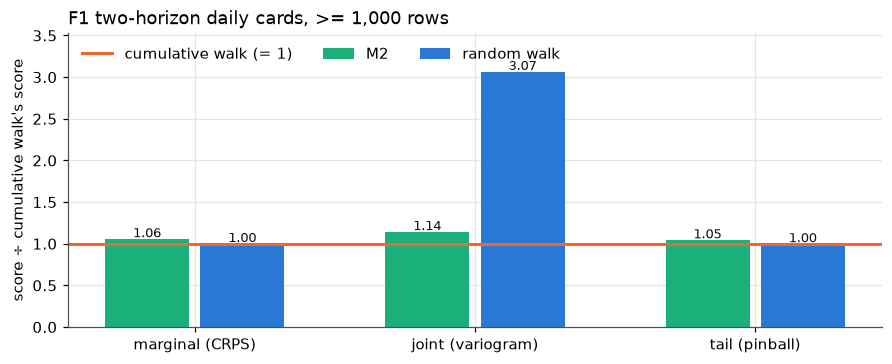

In [5]:
f1 = ok[(ok.family == "T2-F1") & ok.horizons.str.contains(",") & (ok.freq == "daily") & (ok.n_train >= 1000)]
PARTS = ["marginal", "joint", "tail", "composite"]
rel = pd.DataFrame({part: {m: float(np.exp(np.log(pv[m] / pv["cumulative walk"]).mean())) for m in ("M2", "random walk")}
                    for part in PARTS
                    for pv in [f1.pivot_table(index=["unit", "origin"], columns="model", values=part)]})
rel["90% coverage"] = f1.groupby("model").cov90.mean().reindex(rel.index)
print(f"{f1.unit.nunique()} cards, {f1.origin.nunique()} dates. Relative to the cumulative walk (its 90% coverage: "
      f"{f1[f1.model == 'cumulative walk'].cov90.mean():.3f}):")
display(rel.round(3))

fig, ax = plt.subplots(figsize=(8, 3.2), layout="constrained")
x = np.arange(3); wbar = 0.34
for j, name in enumerate(["M2", "random walk"]):
    ax.bar(x + (j - 0.5) * wbar, rel.loc[name, ["marginal", "joint", "tail"]], width=wbar - 0.04, color=COL[name], label=name)
    for xi, v in zip(x, rel.loc[name, ["marginal", "joint", "tail"]]):
        ax.text(xi + (j - 0.5) * wbar, v + 0.02, f"{v:.2f}", ha="center", fontsize=8.5, color=INK)
ax.axhline(1, color=COL["cumulative walk"], lw=2, label="cumulative walk (= 1)")
ax.set_xticks(x, ["marginal (CRPS)", "joint (variogram)", "tail (pinball)"])
ax.set_ylabel("score ÷ cumulative walk's score"); ax.legend(ncols=3, loc="upper left")
ax.set_ylim(0, max(1.3, float(rel[["marginal", "joint", "tail"]].to_numpy().max()) * 1.15))
ax.set_title("F1 two-horizon daily cards, >= 1,000 rows"); plt.show()

- The **random walk** has the same centre and width as the cumulative walk, so its **marginal** and **tail**
  are the same (1.00). Its **joint** is about **3× worse**: it draws the 126-day and 189-day values
  independently, so its draws can have them move in opposite directions.
- **M2** is a little worse than the cumulative walk on all three parts (about +6% marginal, +14% joint,
  +5% tail). It links the horizons too (one historical date per draw), but less exactly than a path.

That is why M2 beat the *old* walk on F1 last week, and why it now loses slightly to the cumulative walk.

## 5 — Monthly cards: the horizon fix

On a monthly panel one row is one month, but the cards state their horizons in business days (21, or 140
and 160). The walk's width is `sd per step × √steps`, and it used to put the business days straight into
`√`: 21 business days became 21 *months*, about 3× too wide (4× on the CPI card).

**Fixed on `feat/model_v2`:** `forecast_models._panel_steps` counts, on monthly panels only, the months
from the asset's last observation to the month of `as-of + h business days`, the official baseline's
rule (docs/M0-BASELINE.md §3.7). Daily cards are untouched: all their walk outputs are bit-for-bit
identical to before the fix.

First, the step counts production now uses at each card's real as-of, next to the official baseline's
table and M2's:

In [6]:
M0_TABLE = {"t2-F1-cpi-glidepath-2023": [8, 9], "t2-F1-sahm-watch-2024": [8, 9],
            "t2-F4-covid-nfp-2020": [2], "t2-F4-cpi-vintage-2022": [2]}
rows = []
for u, m0 in M0_TABLE.items():
    ud = REPO / "units" / u; card_t = tomllib.loads((ud / "card.toml").read_text()); t = card_t["targets"]
    A, H = [str(a) for a in t["asset_ids"]], [int(h) for h in t["horizons"]]
    asof = card_t["provenance"]["data_cutoff"]; panels = fa._read_panels(ud)
    fit = fm._fit_walk(fm._Request(panels, A, H, asof, {A[0]: {}}, 10, 0, t["target_type"], None))
    unit = m2.unit_from_panels(panels, A, H, asof, t["target_type"])
    rows.append({"card": u, "horizons (BD)": H, "last observation": unit.wide[A[0]].dropna().index[-1].date(),
                 "as-of": asof, "walk steps (fixed)": fit.steps[0].astype(int).tolist(),
                 "official M0 table": m0, "M2": [m2.steps_ahead_for(unit, h) for h in H]})
pd.DataFrame(rows).set_index("card")

,horizons (BD),last observation,as-of,walk steps (fixed),official M0 table,M2
card,,,,,,
t2-F1-cpi-glidepath-2023,"[140, 160]",2023-05-01,2023-07-12,"[8, 9]","[8, 9]","[8, 9]"
t2-F1-sahm-watch-2024,"[145, 165]",2024-06-01,2024-08-02,"[8, 9]","[8, 9]","[8, 9]"
t2-F4-covid-nfp-2020,[21],2020-02-01,2020-03-31,[2],[2],[2]
t2-F4-cpi-vintage-2022,[21],2022-04-01,2022-05-31,[2],[2],[2]


Now the backtest: the walk **before** the fix, the walk **after** it, and M2, on the same dates.

(At a past date the panel has no publication delay, so re-deriving months there would miscount. The fixed
walk is given the card's own step count, which is exactly what production computes at the real as-of,
as the table above shows. `backtest_m2.py` does the same.)

In [7]:
rows = []
for u in M0_TABLE:
    ud = REPO / "units" / u; card_t = tomllib.loads((ud / "card.toml").read_text()); t = card_t["targets"]
    A, H = [str(a) for a in t["asset_ids"]], [int(h) for h in t["horizons"]]
    panels = fa._read_panels(ud); small = bt._only_assets(panels, A)
    unit = m2.unit_from_panels(panels, A, H, card_t["provenance"]["data_cutoff"], t["target_type"])
    cells = m2.build_features(unit); card_steps = np.array([float(c.steps) for c in cells[:len(H)]])
    neutral = {a: {"shift": 0.0, "widen": 1.0, "skew": 0.0} for a in A}
    at = [dict(zip(c.frame.origin_date, range(len(c.frame)))) for c in cells]
    walk = fm._cumulative_walk_model if len(H) > 1 else fm._random_walk_model
    variants = {"walk before the fix": lambda s_, hz, a_: np.array(hz, float),   # business days used as steps
                "walk after the fix": lambda s_, hz, a_: card_steps}
    s = {"M2": [], **{k: [] for k in variants}}
    for k, o in enumerate(bt._origins(cells, unit.freq)):
        y = np.array([c.frame.target.to_numpy(float)[at[j][o]] for j, c in enumerate(cells)])
        s["M2"].append(bt.score_composite(m2.draw_joint([m2.fit_m2(c, origin=o) for c in cells], 1000, k), y)["composite"])
        req = fm._Request(small, A, H, str(o.date()), neutral, 1000, k, t["target_type"], card_t["metadata"]["category"])
        for lab, steps_fn in variants.items():
            saved, fm._panel_steps = fm._panel_steps, steps_fn
            try:
                s[lab].append(bt.score_composite(walk(req).reshape(1000, -1), y)["composite"])
            finally:
                fm._panel_steps = saved
    s = {k: np.array(v) for k, v in s.items()}
    geo = lambda a, b: float(np.exp(np.log(a / b).mean()))
    rows.append({"card": u, "dates": len(s["M2"]),
                 "walk after ÷ walk before": geo(s["walk after the fix"], s["walk before the fix"]),
                 "M2 ÷ walk before": geo(s["M2"], s["walk before the fix"]),
                 "M2 ÷ walk after": geo(s["M2"], s["walk after the fix"])})
pd.DataFrame(rows).set_index("card").round(3)

,dates,walk after ÷ walk before,M2 ÷ walk before,M2 ÷ walk after
card,,,,
t2-F1-cpi-glidepath-2023,96,0.757,0.405,0.536
t2-F1-sahm-watch-2024,103,0.428,0.354,0.826
t2-F4-covid-nfp-2020,84,0.740,0.347,0.469
t2-F4-cpi-vintage-2022,97,0.725,0.476,0.657


- The fix makes the walk better on all four cards (first column below 1).
- **M2 still beats the fixed walk** on all four (last column below 1), so M2 is the better model on
  monthly cards, not just the less broken one.
- In production, F1's two monthly cards use M2; F4's two monthly cards use the walk, which is now fixed.

## 6 — Every card

Each dot is one card: its geometric-mean ratio over all its backtest dates. Left of the line, M2 was better.

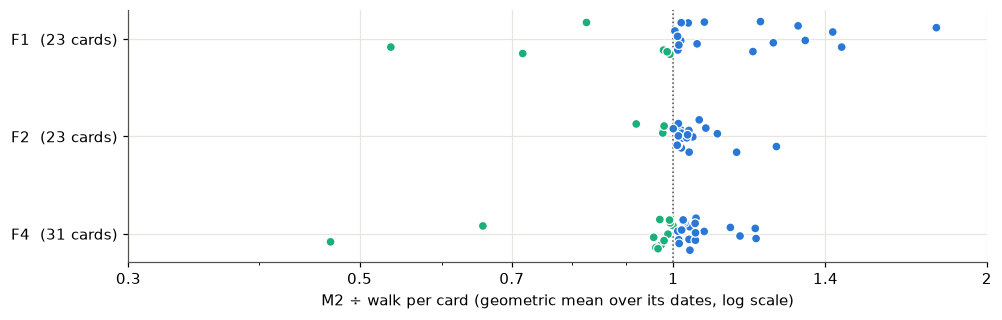

,family,unit,freq,target_type,horizons,walk_name,dates,geo_mean_ratio,M2_wins_%
7,T2-F1,t2-F1-cpi-glidepath-2023,monthly,level,"[140, 160]",cumulative walk,96.0,0.536,80.208
5,T2-F1,t2-F1-considerable-period-2003,daily,level,"[126, 189]",cumulative walk,2.0,0.717,50.000
20,T2-F1,t2-F1-sahm-watch-2024,monthly,level,"[145, 165]",cumulative walk,103.0,0.826,68.932
10,T2-F1,t2-F1-fed-put-2019,daily,log_return,[128],random walk,197.0,0.979,54.822
16,T2-F1,t2-F1-normalization-2017,daily,level,[127],random walk,172.0,0.987,48.256
9,T2-F1,t2-F1-eur-range-2017,daily,level,"[126, 189]",cumulative walk,170.0,0.993,49.412
1,T2-F1,t2-F1-aud-on-hold-2016,daily,level,"[126, 189]",cumulative walk,160.0,1.004,48.125
19,T2-F1,t2-F1-qe3-end-2014,daily,level,"[126, 189]",cumulative walk,135.0,1.010,46.667
4,T2-F1,t2-F1-conflicting-texts-2024,daily,level,"[126, 189]",cumulative walk,250.0,1.010,46.400
22,T2-F1,t2-F1-ust-positioning-2018,daily,level,"[126, 189]",cumulative walk,182.0,1.013,46.703


In [8]:
fig, ax = plt.subplots(figsize=(9, 2.8), layout="constrained")
fams = ["T2-F1", "T2-F2", "T2-F4"]
for i, f in enumerate(fams):
    c = card[card.family == f]
    jitter = np.random.default_rng(i).uniform(-0.18, 0.18, len(c))
    ax.scatter(c.geo_mean_ratio, i + jitter, s=34, color=[COL["M2"] if v < 1 else COL["random walk"] for v in c.geo_mean_ratio],
               edgecolor="white", linewidth=0.8, zorder=3)
ax.axvline(1, color=INK2, lw=1, ls=":")
ax.set_yticks(range(3), [f"{f[3:]}  ({(card.family == f).sum()} cards)" for f in fams]); ax.invert_yaxis()
ax.set_xscale("log"); ax.set_xticks([0.3, 0.5, 0.7, 1, 1.4, 2]); ax.set_xticklabels(["0.3", "0.5", "0.7", "1", "1.4", "2"])
ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax.set_xlabel("M2 ÷ walk per card (geometric mean over its dates, log scale)"); plt.show()
card.sort_values(["family", "geo_mean_ratio"]).round(3)

## 7 — Check on real outcomes (the team's local eval)

§1–§6 only use each card's own history. This section is different: it forecasts at each F1 card's real
as-of date, exactly as the submission does (`forecast_agent.main`, text adjustments included), and scores
against the **realized vector** the team's eval uses (`realized_vectors/`, the same files `run_eval.py`
reads). Two runs per card: the v2 routing (M2, with the history router) and the walk for the card's shape.

Only 18 F1 cards have a realized vector, and each gives one outcome, so this is a small sample. It takes
about a minute.

In [9]:
def run_card(ud, select):
    asof = tomllib.loads((ud / "card.toml").read_text())["provenance"]["data_cutoff"]
    saved = fm._select_model; fm._select_model = select
    try:
        with tempfile.TemporaryDirectory() as tmp:
            out = pathlib.Path(tmp) / "forecast.parquet"
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                fa.main(["--panels", str(ud), "--text", str(ud / "text"), "--asof", asof, "--out", str(out)])
            used = fm.last_model()
            res = subprocess.run([sys.executable, "scoring/scoring.py", "score", "--card", str(ud / "card.toml"),
                                  "--forecast", str(out), "--realized", f"realized_vectors/{ud.name}.parquet"],
                                 capture_output=True, text=True, cwd=REPO)
            return used, json.loads(res.stdout)["composite_score"]
    finally:
        fm._select_model = saved

ev = []
for ud in sorted((REPO / "units").glob("t2-F1-*")):
    if not (REPO / "realized_vectors" / f"{ud.name}.parquet").exists():
        continue
    m_used, m_score = run_card(ud, fm._select_model)
    w_used, w_score = run_card(ud, lambda f, t, h: fm._walk_for(h))
    ev.append({"card": ud.name, "v2 model": m_used, "v2 score": m_score, "walk": w_used, "walk score": w_score,
               "v2 ÷ walk": m_score / w_score})
ev = pd.DataFrame(ev).set_index("card")
r = ev.loc[ev["v2 model"] == "M2", "v2 ÷ walk"]
print(f"{len(ev)} scored F1 cards.  Raw mean score: v2 {ev['v2 score'].mean():.4f}, walk everywhere {ev['walk score'].mean():.4f}")
print(f"Cards where v2 uses M2: {len(r)}.  M2 better on {(r < 1).sum()}/{len(r)}; geometric mean M2 ÷ walk = {np.exp(np.log(r).mean()):.3f}")
ev.round(4)

18 scored F1 cards.  Raw mean score: v2 0.2790, walk everywhere 0.2354
Cards where v2 uses M2: 15.  M2 better on 5/15; geometric mean M2 ÷ walk = 1.105


,v2 model,v2 score,walk,walk score,v2 ÷ walk
card,,,,,
t2-F1-aud-on-hold-2016,M2,0.0132,cumulative walk,0.0121,1.0924
t2-F1-cad-boc-2017,M2,0.0142,cumulative walk,0.0161,0.8838
t2-F1-chf-highly-valued-2021,M2,0.0137,cumulative walk,0.0079,1.7202
t2-F1-considerable-period-2003,cumulative walk,0.1745,cumulative walk,0.1745,1.0000
t2-F1-conundrum-2005,cumulative walk,0.0927,cumulative walk,0.0927,1.0000
t2-F1-dkk-peg-2019,M2,0.1370,random walk,0.1088,1.2592
t2-F1-eur-range-2017,M2,0.0155,cumulative walk,0.0147,1.0548
t2-F1-fed-put-2019,M2,0.0227,random walk,0.0211,1.0746
t2-F1-greater-confidence-2024,M2,0.2354,cumulative walk,0.4611,0.5105


On real outcomes the walk does better than M2 on most F1 daily cards. This agrees with §3–§4: the
cumulative walk is now a strong baseline, and M2's features do not add enough on daily data. (The two
monthly F1 cards, where M2 wins in the backtest, have no realized vector, so they are not in this table.)

## 8 — What this means, and the options

| cards | evidence | suggestion |
|---|---|---|
| F2 | M2 worse (§3, §6) | keep the random walk |
| F4 daily | M2 worse or tied (§3) | keep the walk |
| monthly cards (F1 ×2, F4 ×2) | M2 better than the fixed walk (§5) | use M2 (the walk's monthly horizon is fixed on `feat/model_v2`) |
| F1 daily, < 1,000 rows | walk better (§3) | walk — already done by the router |
| F1 daily, ≥ 1,000 rows | walk slightly better in the backtest (§3, §4) and on real outcomes (§7) | open question — see options |

**Options for F1 daily cards:**

- **A. Route by evidence:** M2 only on monthly cards; the walk on daily cards.
- **B. Blend:** take half the draws from M2 and half from the walk. They are close, and each wins on about
  half the dates; a mixture of two good forecasts often beats both. This can be tested with the same
  backtest before deciding.
- **C. Improve M2:** its centre (μ) and width (σ) are not beating a 260-day walk on daily data. Better
  features or a different width model would be needed.

**Rule for deciding:** use the backtest (thousands of dates) to choose, and the team eval (18 outcomes) only
to check. Choosing per card from the eval would fit noise.